In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import h5py
import pandas as pd
import os
import xarray as xr
import seaborn as sns
import warnings

# Warnings configuration
warnings.simplefilter(action='ignore', category=FutureWarning)
np.seterr(divide='ignore', invalid='ignore')

# General plotting settings
sns.set_style('ticks')
sns.set_context("talk", font_scale=.8, rc={"lines.linewidth": 2.5})
%matplotlib inline

### Setup

In [2]:
def calc_IFD(da, sic_threshold=0.15, DOY_s=1, time_dim='time'):
    '''
    Calc the Ice Free Day (first) by Calender Year.
    '''
    da = da.set_index(time='time')
    ifd = (da < sic_threshold).reduce(np.argmax, dim='time')  # Find index of first ice free
    ifd = ifd.where(da.isel(time=0).notnull())  # Apply Orig mask
    ifd = ifd + DOY_s  # Convert to Day of Year by adding the first time 
    return ifd


def calc_IFD_10day(da, sic_threshold=0.5, DOY_s=1, time_dim='time', Nday=10, default_ice_free=None):
    '''
    Calc the Ice Free Day (first) by Calender Year.

    Returns day of year (doy) for each pixel when the sic value
    dropped below the sic_threshold and stayed below that threshold
    for atleast Nday days.
    '''

    da = da.set_index(time='time')

    # Here we find pixels WITHOUT (<sic_threshold) Ice!!!
    sip_Xday = (da < sic_threshold).rolling(min_periods=1, center=False, time=Nday).sum().where(da.isel(time=0).notnull()) 

    # Now values range from 0 to Nday, keep only Nday pixel values, rescale them to 1 (end up with 0 with ice and 1 with ocean over past 10 days)
    sip_Xday_adj = sip_Xday.where(sip_Xday == Nday, other=0).where(da.isel(time=0).notnull())
    sip_Xday_adj = sip_Xday_adj.astype('float') / Nday

    # Now reduce over time dime, and find the first "1" value for each pixel (which is the last day of ice presence, with at least 10 days following ice free)
    ifd = sip_Xday_adj.reduce(np.argmax, dim='time')  # Find index of first ice free

    # Convert to Day of Year by adding the first time
    ifd = ifd + DOY_s - Nday - 1  # Add DOY_s and subtract the Nday window (rolling returns the right side label "trailing")

    # Classify pixels
    # 1) that were ice free at first index time to the default ice free date (i.e. June 1st)
    ifd = ifd.where(ifd > DOY_s, other=default_ice_free)

    # 2) that never melted (perenial) to NaN
    # Grab last model time (end of Sept) and get mask of where ice is
    # perenial_ice_mask = (da.isel(time=da.time.size-1) >= sic_threshold)
    # instead make the perennial mask true ice is never below 0.5
    perenial_ice_mask = (da.min(dim='time') >= sic_threshold)
    ifd = ifd.where(~perenial_ice_mask, other=275)

    # Apply Orig mask
    ifd = ifd.where(da.isel(time=0).notnull())

    return ifd


def MakeDataSet2(FILE_NAME):
    '''
    Function for reading the 12.5 km observations of sea ice concentration.
    '''

    SIC = '/HDFEOS/GRIDS/NpPolarGrid12km/Data Fields/SI_12km_NH_ICECON_DAY'
    LAT = '/HDFEOS/GRIDS/NpPolarGrid12km/lat'
    LON = '/HDFEOS/GRIDS/NpPolarGrid12km/lon'
    NI = '/XDim'
    NJ = '/YDim'

    f = h5py.File(FILE_NAME, mode='r')
    data = f[SIC][:]
    lat = f[LAT][:]
    lon = f[LON][:]
    ni = f[NI][:]
    nj = f[NJ][:]

    ds = xr.DataArray(np.transpose(data), dims=["ni", "nj"])
    ds.name = 'sic'
    lat = xr.DataArray(np.transpose(lat), dims=["ni", "nj"])
    lon = xr.DataArray(np.transpose(lon), dims=["ni", "nj"])
    ds = ds.where(ds <= 100, other=np.nan)
    ds.coords['lon'] = lon
    ds.coords['lat'] = lat
    ds.coords['nj'] = nj
    ds.coords['ni'] = ni

    result = FILE_NAME.find('he5')
    date = FILE_NAME[result-9:result-1]
    cyear = date[0:4]
    cmonth = date[4:6]
    cday = date[6:8]

    ds.coords['time'] = np.datetime64(f"{cyear}-{cmonth}-{cday}", 'ns')
    ds.time

    f.close()

    return (ds, lat, lon)

In [3]:
# Customize this cell
fig_dir = './figures/'
CB_lon = [-105.0597]
CB_lat = [69.1169]  # 69.1169° N, 105.0597° W

stero_grid_file = "stereo_gridinfo.nc"
obs_grid = xr.open_dataset(stero_grid_file)

# Fix any values slightly above 90
obs_grid["grid_corner_lat"] = obs_grid.grid_corner_lat.where(
    obs_grid.grid_corner_lat < 90, other=90
)

# Also ensure centers are within [-90, 90]
obs_grid["grid_center_lat"] = obs_grid.grid_center_lat.clip(-90, 90)

# Colormaps
cmap_c = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", "orange", "red", "#990000"], N=10)
cmap_c.set_bad(color='lightgrey')

cmap_std = matplotlib.colors.ListedColormap(sns.color_palette("Blues", 10))
cmap_std.set_bad(color='lightgrey')

cmap_b = matplotlib.colors.ListedColormap(sns.color_palette("binary", 2))
cmap_b.set_bad(color='None')

### Version 1

In [4]:
IFD_all, IFD2_all, sic_CB = [], [], []

for yr in np.arange(2013, 2025):
    sic_all = []
    for mo in np.arange(5, 10):
        for day in np.arange(1, 32):
            mostr = "{:02d}".format(mo)
            daystr = "{:02d}".format(day)
            FILE_NAME = '/glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_'+str(yr)+mostr+daystr+'.he5'
            try:
                sic, lat, lon = MakeDataSet2(FILE_NAME)
                sic = sic.isel(nj=slice(500, 605)).isel(ni=slice(110, 190))
                sic = sic.expand_dims('time')
                sic_all.append(sic)
            except:
                if yr == 2013 and mo == 5 and day in [11, 12, 13]:
                    sic['time'] = sic['time']+np.timedelta64(1, 'D')
                    sic_all.append(sic)
                    ni = sic.ni
                    nj = sic.nj
                print('No data found:', FILE_NAME)

    sic_all = xr.concat(sic_all, dim='time')
    if yr > 2022:  # Strange that the data sets lose this
        sic_all['ni'] = ni
        sic_all['nj'] = nj

    sic_CB.append(sic_all.sel(ni=148, nj=558))

    DOY = np.arange(121, 121+len(sic_all['time']))
    sic_all.coords['doy'] = xr.DataArray(DOY, dims='time', coords={'time': sic_all.time})

    sic_IFD = calc_IFD(sic_all/100, sic_threshold=0.70, DOY_s=121)
    sic_IFD2 = calc_IFD_10day(sic_all/100, sic_threshold=0.5, DOY_s=121, Nday=6)
    sic_IFD.name = 'IFD'
    sic_IFD2.name = 'IFD2'

    sic_IFD = sic_IFD.expand_dims('time')
    sic_IFD2 = sic_IFD2.expand_dims('time')

    IFD_all.append(sic_IFD)
    IFD2_all.append(sic_IFD2)

IFD_all = xr.concat(IFD_all, dim='time')
IFD_all = IFD_all.set_index(time='time')  # IFD_all = IFD_all.swap_dims({"time": "year"})
IFD_all.coords['year'] = xr.DataArray(np.arange(2013, 2025), dims='time', coords={'time': IFD_all.time})

IFD2_all = xr.concat(IFD2_all, dim='time')
IFD2_all = IFD2_all.set_index(time='time')  # IFD2_all = IFD2_all.swap_dims({"time": "year"})
IFD2_all.coords['year'] = xr.DataArray(np.arange(2013, 2025), dims='time', coords={'time': IFD2_all.time})
IFD2_all = IFD2_all.astype(float)

sic_CB = xr.concat(sic_CB, dim='time')

No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20130511.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20130512.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20130513.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20130631.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20130931.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20140631.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20140931.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20150631.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20150931.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_20

KeyError: "no index found for coordinate 'year'"

<Figure size 640x480 with 0 Axes>

In [6]:
# Plots
plt.figure()
IFD2_all.sel(year=2016).plot()
plt.show()

plt.subplot(121)
IFD_all.sel(year=2016).plot()
plt.plot(558, 148, color='r', marker='*')
plt.subplot(122)
IFD2_all.sel(year=2016).plot()
plt.plot(558, 148, color='r', marker='*')
plt.show()

cmap_i = matplotlib.colors.LinearSegmentedColormap.from_list("", ["yellow", "green", "blue"], N=40)
cmap_i.set_bad(color='lightgrey')
ncols = 4
nrows = 3
(f, axes) = plt.subplots(ncols=ncols, nrows=nrows)
f.set_size_inches(ncols*4, nrows*4)
axes = axes.flatten()
i = 0
for i, yr in enumerate(np.arange(2013, 2025)):
    axi = axes[i]
    p = IFD2_all.sel(year=yr).plot(ax=axi, x='lon', y='lat', vmin=150, vmax=220, add_colorbar=False, cmap=cmap_i)
    axi.plot([CB_lon], [CB_lat], color='r', marker='*')
    axi.set_ylim([67, 71])
    axi.set_xlim([-120, -95])
    axi.set_ylim([68, 71])
    axi.set_xlim([-122, -92])
    axi.set_title(str(yr))
    if i != 8:
        axi.axis('off')
    f.subplots_adjust(bottom=0.05)
cbar_ax = f.add_axes([0.25, 0.001, .55, 0.015])  # [left, bottom, width, height]
cbar = f.colorbar(p, cax=cbar_ax, label='First Ice Free Day', orientation='horizontal')
f_out = os.path.join(fig_dir, 'IFD2_Allyears_2013-2024.png')
f.savefig(f_out, bbox_inches='tight', dpi=300)
print("Saved:", f_out)
plt.show()

(fig, axes) = plt.subplots(1, 1)
fig.set_size_inches(8, 4)
IFD2_all.sel(ni=148, nj=558).plot()
plt.title("Cambridge Bay First Ice Free Day")
plt.ylabel("IFD [day of year]")
f_out = os.path.join(fig_dir, 'Cambridge_Bay_IFD_2013-2024.png')
fig.savefig(f_out, bbox_inches='tight', dpi=300)
print("Saved:", f_out)
plt.show()

KeyError: "no index found for coordinate 'year'"

<Figure size 640x480 with 0 Axes>

### Version 2

In [7]:
yr = 2016
sic_all = []
for mo in np.arange(5, 10):
    for day in np.arange(1, 32):
        mostr = "{:02d}".format(mo)
        daystr = "{:02d}".format(day)
        FILE_NAME = '/glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_'+str(yr)+mostr+daystr+'.he5'
        try:
            sic, lat, lon = MakeDataSet2(FILE_NAME)
            sic = sic.isel(nj=slice(500, 605)).isel(ni=slice(110, 190))
            sic = sic.expand_dims('time')
            sic_all.append(sic)
        except:
            if yr == 2013 and mo == 5 and day in [11, 12, 13]:
                sic['time'] = sic['time']+np.timedelta64(1, 'D')
                sic_all.append(sic)
                ni = sic.ni
                nj = sic.nj
            print('No data found:', FILE_NAME)
sic_all = xr.concat(sic_all, dim='time')
DOY = np.arange(121, 121+len(sic_all['time']))
sic_all.coords['doy'] = xr.DataArray(DOY, dims='time', coords={'time': sic_all.time})

No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20160631.he5
No data found: /glade/work/skygale/data/AMSR2_12.5km_2012_Present/AMSR_U2_L3_SeaIce12km_B04_20160931.he5


Saved: ./figures/Cambridge_Bay_SIC_MaytoJuly_2013-2024.png


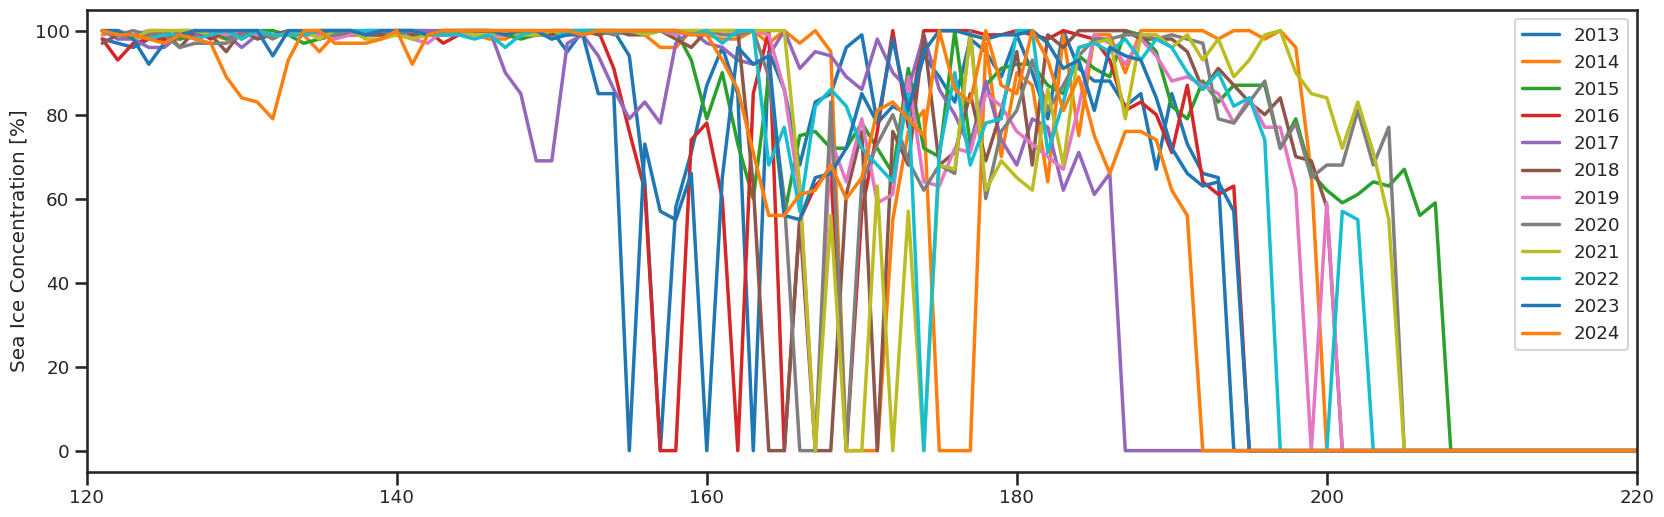

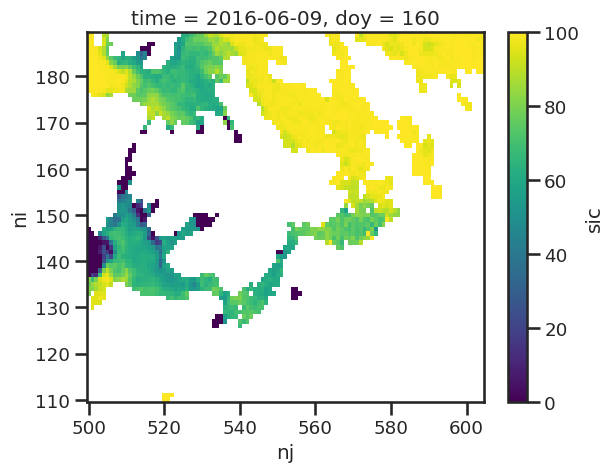

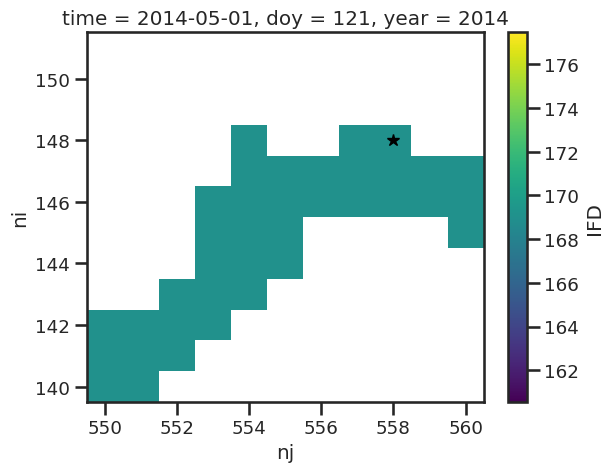

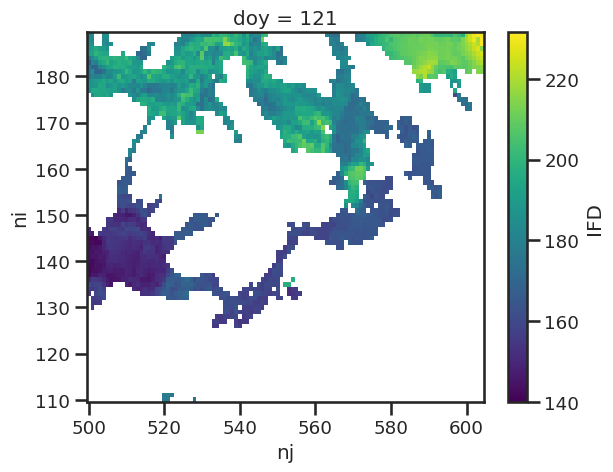

In [17]:
# Plots
(fig, axes) = plt.subplots(1, 1)
fig.set_size_inches(20, 6)
for yr in np.arange(2013, 2025):
    plt.plot(DOY, sic_CB[pd.to_datetime(sic_CB.time.data).year == yr], label=str(yr))
plt.xlim([120, 220])
plt.legend()
plt.ylabel('Sea Ice Concentration [%]')
f_out = os.path.join(fig_dir, 'Cambridge_Bay_SIC_MaytoJuly_2013-2024.png')
fig.savefig(f_out, bbox_inches='tight', dpi=300)
print("Saved:", f_out)

plt.figure()
sic_all.isel(time=159-120).plot()  # Obviously there are bad points occuring in bays and channels
plt.show()

plt.figure()
IFD_all.isel(time=1).sel(ni=range(140, 152), nj=range(550, 561)).plot()
plt.plot(558, 148, color='k', marker='*')
plt.show()

plt.figure()
IFD_all.mean(dim='time').plot()
plt.show()